In [2]:
%load_ext autoreload
%autoreload 2

import sys

PROJECT = "/Users/Guille/Desktop/dynamic_update/functional_forecast_dynamic_update"

sys.path.insert(0, PROJECT)

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from skfda import FDataGrid
from skfda.exploratory.depth import IntegratedDepth, ModifiedBandDepth

from matplotlib_scalebar.scalebar import ScaleBar

from src import loader, plotter

from src.config import DATA, DEPTH, IMAGES, VALIDATION, TABLES
from src.fda import _fDepth, _fQuantile
from src.fdu import functional_dynamic_update
from src.utils import KS, get_band_fraction, get_hyper, mask_intervals

# Loading color palette
palette_ = pd.read_csv(DATA / "palette.csv")

# Loading Texas map
_TX = gpd.read_file(DATA / "maps/TX/State.shp")

T = 288
method = "fusion"
resource = "solar"
aggregation = "asset"

# Historical random curves and day-ahead forecasts

In [3]:
(
    F_tr_,
    F_ts_,
    E_tr_,
    E_ts_,
    X_tr_,
    X_ts_,
    T_tr_,
    T_ts_,
    assets_tr_,
    assets_ts_,
    t_tr_,
    t_ts_,
    dt_,
    dx_,
) = loader.preprocessed_dataset(
    unbiased=True,
    path_to_training_data=DATA / "preprocessed_solar_2017.pkl",
    path_to_testing_data=DATA / "preprocessed_solar_2018.pkl",
    T=288,
)
print(F_tr_.shape, F_ts_.shape)
print(E_tr_.shape, E_ts_.shape)
print(X_tr_.shape, X_ts_.shape)
print(T_tr_.shape, T_ts_.shape)
print(assets_tr_.shape, assets_ts_.shape)
print(t_tr_.shape, t_ts_.shape)
print(dt_.shape, dx_.shape)

E_tr_lin_, E_ts_lin_ = loader.processed_dataset(
    unbiased=True,
    path_to_training_data=DATA / "linear_preprocessed_solar_2017.pkl",
    path_to_testing_data=DATA / "linear_preprocessed_solar_2018.pkl",
    T=288,
)
print(E_tr_lin_.shape, E_ts_lin_.shape)

E_tr_biased_, E_ts_biased_ = loader.processed_dataset(
    unbiased=False,
    path_to_training_data=DATA / "preprocessed_solar_2017.pkl",
    path_to_testing_data=DATA / "preprocessed_solar_2018.pkl",
    T=288,
)
print(E_tr_biased_.shape, E_ts_biased_.shape)

(76593, 288) (364, 288, 211)
(76593, 288) (364, 288, 211)
(76593, 2) (211, 2)
(76593, 288) (364, 288)
(76593, 1) (211,)
(76593,) (364,)
(288,) (288,)
(76593, 288) (364, 288, 211)
(76593, 288) (364, 288, 211)


In [12]:
exp_description="unbiased-025"
_init = {120: 4, 144: 4, 168: 2}

exp_description="biased-025"
_init = {120: 1, 144: 2, 168: 4}

hyper_, envelope_ = loader.hyperparameters(
    _init,
    resource,
    method,
    aggregation,
    exp_description,
    path_to_validation = VALIDATION,
)

hyper_.loc['length_scale_f'] = 1./hyper_.loc['tau']
hyper_.loc['length_scale_e'] = hyper_.loc['length_scale_f']*hyper_.loc['rho_e']
hyper_.loc['length_scale_d'] = hyper_.loc['length_scale_f']*hyper_.loc['rho_d']
print(hyper_)
# print(envelope_)

stats_, funcs_ = loader.get_stats(
    _init, 
    resource, 
    method, 
    aggregation, 
    exp_description, 
    T, 
    VALIDATION, 
)
# print(stats_)
# print(funcs_)

time                    120          144          168
p_fusion           0.750000     0.750000     0.750000
forget_rate_f      0.125000     0.125000     0.125000
forget_rate_e      1.000000     1.000000     1.000000
lookahead_rate     4.000000     4.000000     4.000000
tau                0.001000     0.001000     0.001000
kappa            150.000000   150.000000   150.000000
rho_e              0.005520     0.006408     0.011414
rho_d              0.000851     0.003223     0.024644
kappa_0          667.000000   504.000000   480.000000
nu                 6.000000     3.000000     3.000000
sigma              0.000000     0.000000     0.000000
length_scale_f  1000.000000  1000.000000  1000.000000
length_scale_e     5.520232     6.407654    11.414064
length_scale_d     0.850801     3.222521    24.643697


# Functional kNNs dynamic update

Atascosa I Solar 2018-05-01 12:00:00
0.01
0.361
182.0
1.0
(6341,)
(665,)
(182,)
solar-11-120-144-asset


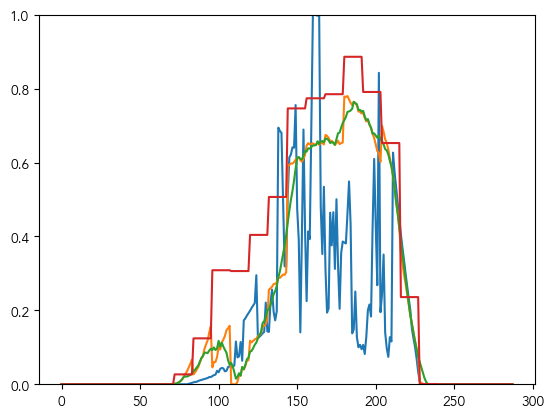

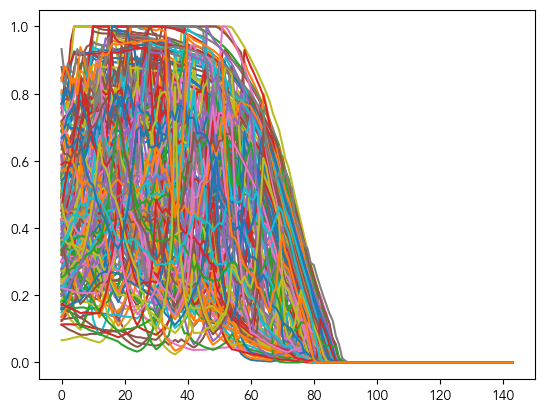

In [136]:
day = 120
asset = 11
interval = 144

_fdu = functional_dynamic_update(
    _distances = {"temporal": "seasonal_equinox", "spatial": "haversine", 'fusion': 'dynamic'},
    name = assets_ts_[asset],
    date = T_ts_[day, interval],
)
print(_fdu.name, _fdu.date)

# Filter solar hours with loading solar set
interval_mask = mask_intervals(F_tr_, E_tr_biased_, t_tr_, day, day_window=7)

_fdu.fit(
    F_tr_,
    E_tr_lin_,
    dt_,
    X_=X_tr_,
    t_=t_tr_,
    interval_mask=interval_mask,
    n_samples_per_hour=12,
)

M_ = _fdu.predict(
    F_ts_[day, :interval, asset], E_ts_lin_[day, :, asset], X_ts_[asset, :], t_ts_[day],          
    forget_rate_f = get_hyper(hyper_, 'forget_rate_f', interval),
    forget_rate_e = get_hyper(hyper_, 'forget_rate_e', interval),
    length_scale_f = get_hyper(hyper_, 'length_scale_f', interval),
    length_scale_e = get_hyper(hyper_, 'length_scale_e', interval),
    lookup_rate = get_hyper(hyper_, 'lookup_rate', interval),
    trust_rate = get_hyper(hyper_, 'trust_rate', interval),
    nu = get_hyper(hyper_, 'nu', interval)/12,
    gamma = get_hyper(hyper_, 'gamma', interval),
    xi = get_hyper(hyper_, 'xi', interval),
    kappa = get_hyper(hyper_, 'kappa', interval),
    p_fusion = get_hyper(hyper_, 'p_fusion', interval)
)
print(get_hyper(hyper_, 'length_scale_f', interval))
print(get_hyper(hyper_, 'length_scale_e', interval))
print(get_hyper(hyper_, 'kappa', interval))
print(get_hyper(hyper_, 'p_fusion', interval))

print(_fdu.idx_neighbors_.shape)
print(_fdu.idx_temporal_.shape)
print(_fdu.idx_spatial_.shape)

# Plotting variables
e_ = E_ts_[day, :, asset]
e_lin_ = E_ts_lin_[day, :, asset]
e_biased_ = E_ts_biased_[day, :, asset]
f_ = F_ts_[day, :interval, asset]
f_hat_ = F_ts_[day, interval:, asset]
x_ts_ = X_ts_[asset, :]

file_name = f"{resource}-{asset}-{day}-{interval}-asset"
print(file_name)

plt.figure()
plt.plot(F_ts_[day, :, asset])
plt.plot(e_)
plt.plot(e_lin_)
plt.plot(e_biased_)
plt.ylim(0, 1)
plt.show()

plt.figure()
plt.plot(M_.T)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


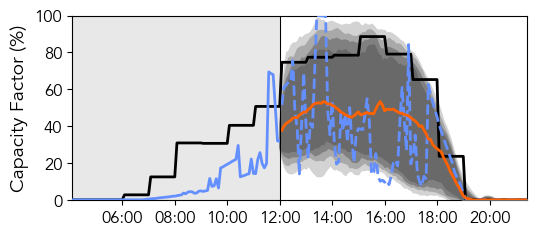

In [137]:
# Calculate confidence intervals from Directional Quantiles
alpha_ = [0.1, 0.2, 0.3, 0.4]
M_int_, M_int_ds_ = _fdu.functional_downsampling(subsample=12, n_basis=20)
f_median_ext_, _upper, _lower = _fdu.ecdf_confidence_bands(M_int_, alpha_)

_fig, _ax = plt.subplots(figsize = (5.25, 2.25), constrained_layout = True)

plotter.plot_envelop(
    _fig, _ax, palette_,
    _upper, _lower, f_median_ext_, f_, f_hat_, e_biased_, dx_,
    dt_=dt_ + 5, 
    interval=interval,
    n=120,
    color=palette_.loc[3, "ibm"],
    CR="CI",
    label=r"$\bar{\mu} (s)$",
    range_ = [48, 256],
    legend_1=False,
    legend_2=False,
)

_ax.legend(
    frameon = False,
    loc = (0.1875, .825),
    fontsize = 12,
    columnspacing=0.5,
    handletextpad=0.25,
    ncol = 5
)

plt.savefig(IMAGES / f"EDF-{file_name}.pdf")

plt.show()

(43200, 156)
-0.12237654320987634 0.19884259259259296
[ 0.14251543 -0.11427469  0.02345679 -0.0121142   0.0117284   0.01342593
 -0.07160494 -0.12237654 -0.06959877  0.19884259]


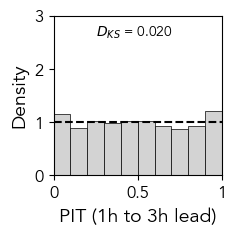

In [90]:
pit_ = loader.pit(
    _init, 
    resource, 
    method, 
    aggregation, 
    interval, 
    exp_description="unbiased-025",
    path_to_validation = VALIDATION
)

print(pit_.shape)

_fig, _ax = plt.subplots(figsize = (2.25, 2.25), constrained_layout = True)

lead = 1
plotter.plot_pit(
    _fig, _ax, pit_[:, lead*12:(lead + 3)*12].flatten(), 
    v = 0.4,
    bins = 10,
    xlabel = 'PIT (1h to 3h lead)'
)

#plt.savefig(path_to_images / f"PIT-{resource}-{lead}-{bins}-{interval}.pdf")

plt.show()

# Visualization Utils

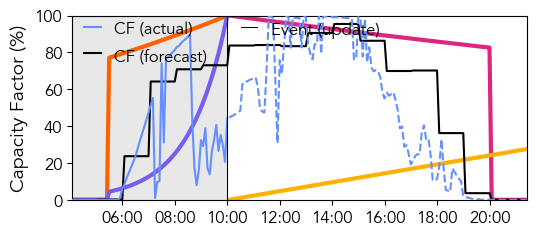

In [121]:
_fig, _ax = plt.subplots(figsize = (5.25, 2.25), constrained_layout = True)

plotter.plot_forecast_parameters(
    _fig, _ax, palette_, 
    _fdu.phi_, _fdu.psi_, _fdu.eta_, 
    f_, f_hat_, e_biased_, dx_, 
    dt_ = dt_ + 5, 
    interval=interval,
    n=120,
    range_=[48, 256],
    labels_1=True,
    labels_2=False
)

_ax.legend(
    frameon=False, 
    ncol=2, 
    loc=(0.0125,0.7), 
    #loc=(0.362,0.625), 
    fontsize=12
)
        
plt.savefig(IMAGES / f"hyper-{file_name}.pdf")

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


21 (21, 144)
13 (13, 144)
9 (9, 144)
6 (6, 144)


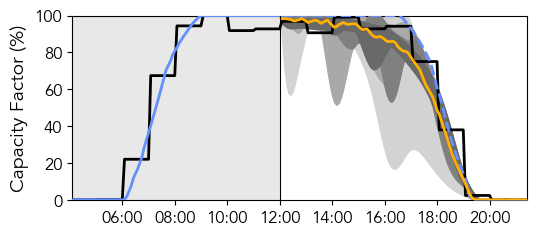

In [53]:
# Samples in each confidence band
score = 'FCS'
distance = "fknn"
alpha_ = [0.1, 0.2, 0.3, 0.4]
_depth = ModifiedBandDepth()

M_int_, M_int_ds_ = _fdu.functional_downsampling(subsample=12, n_basis=20)

J_ = _fdu.focal_curve_envelope(_depth, M_int_, distance)

k_ = get_band_fraction(envelope_, alpha_, interval, distance, score)

f_focal_ext_, _upper, _lower = _fdu.focal_envelop_confidence_bands(alpha_, k_)

_fig, _ax = plt.subplots(figsize = (5.25, 2.25), constrained_layout = True)

plotter.plot_envelop(
    _fig, _ax, palette_,
    _upper, _lower, f_focal_ext_, f_, f_hat_, e_biased_, dx_, 
    dt_ = dt_ + 5,
    interval = interval,
    n=120,
    color=palette_.loc[4, "ibm"],
    label=r"$\bar{f} (s)$",
    CR="CR",
    range_=[48, 256],
    legend_1=False,
    legend_2=False,
)

_ax.legend(
    frameon=False,
    loc=(0.1875, 0.825),
    fontsize=12,
    columnspacing=0.5,
    handletextpad=0.25,
    ncol=5,
)

plt.savefig(IMAGES / f"focal_curve_envelop-{file_name}.pdf")

plt.show()

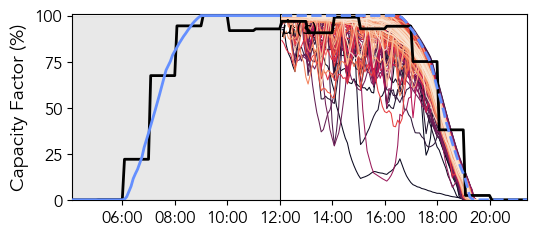

In [8]:
_fig, _ax = plt.subplots(figsize = (5.25, 2.25), constrained_layout = True)

depth = "MBD"
depth_rank_ = _fDepth(_fdu.M_int_ds_, depth, DEPTH).to_numpy()[:, 0]

plotter.plot_depth(
    _fig, _ax, palette_,
    M_, f_, f_hat_, e_biased_, depth_rank_, dx_, 
    dt_ = dt_ + 5, 
    interval = interval,
    n=120,
    range_=[48, 256],
    colorbar=False,
)

_ax.legend(frameon = False,
           loc = (0.4, .825),
           fontsize = 12,
           columnspacing=0.5,
           handletextpad=0.2,
           ncol = 5)

plt.savefig(IMAGES / f"ranking-{depth}_{file_name}.pdf")

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


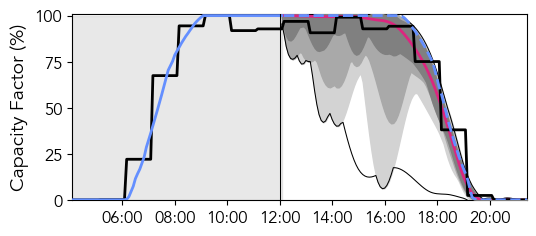

In [9]:
# Calculate confidence intervals from Directional Quantiles
depth = "MBD"
depth_rank_ = _fDepth(_fdu.M_int_ds_, depth, DEPTH).to_numpy()[:, 0]

M_int_, M_int_ds_ = _fdu.functional_downsampling(subsample=12, n_basis=20)
f_deepest_ext_, _upper, _lower = _fdu.functional_boxplot(M_int_, depth_rank_)

_fig, _ax = plt.subplots(figsize = (5.25, 2.25), constrained_layout = True)

plotter.plot_enhanced_functional_boxplot(
    _fig, _ax, palette_,
    _upper, _lower, f_deepest_ext_, f_, f_hat_, e_biased_, dx_, 
    dt_ = dt_ + 5, 
    interval = interval,
    n=120,
    range_=[48, 256],
    legend_1=False,
    legend_2=False,
)

_ax.legend(
    frameon = False,
    loc = (0.1875, .825),
    fontsize = 12,
    columnspacing=0.5,
    handletextpad=0.2,
    ncol = 6
)

plt.savefig(IMAGES / f"fboxplot-{depth}_{file_name}.pdf")

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


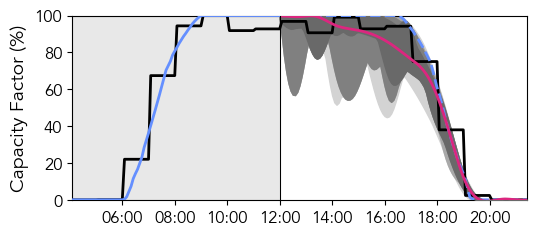

In [55]:
# Samples in each confidence band
score = 'FCS'
distance = 'MBD'
alpha_ = [0.1, 0.2, 0.3, 0.4]
_depth = ModifiedBandDepth()

M_int_, M_int_ds_ = _fdu.functional_downsampling(subsample=12, n_basis=20)

k_ = get_band_fraction(envelope_, alpha_, interval, distance, score)

f_deepest_ext_, _upper, _lower = _fdu.depth_confidence_bands(_depth, M_int_, alpha_, k_)

_fig, _ax = plt.subplots(figsize = (5.25, 2.25), constrained_layout = True)

plotter.plot_envelop(
    _fig, _ax, palette_,
    _upper, _lower, f_deepest_ext_, f_, f_hat_, e_biased_, dx_, 
    dt_ = dt_ + 5, 
    interval=interval,
    n=120,
    color=palette_.loc[2, "ibm"],
    label=r"$\bar{f} (s)$",
    CR="CR",
    range_=[48, 256],
    legend_1=False,
    legend_2=False,
)

_ax.legend(
    frameon=False,
    loc=(0.1875, 0.825),
    fontsize=12,
    columnspacing=0.5,
    handletextpad=0.25,
    ncol=5,
)

plt.savefig(IMAGES / f"deepest_curve_envelop-{file_name}.pdf")

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


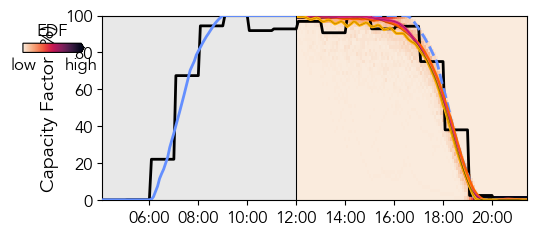

In [16]:
_fig, _ax = plt.subplots(figsize = (5.25, 2.25), constrained_layout = True)

plotter.plot_density_heatmap(
    _fig, _ax, palette_,
    M_, _fdu.f_median_ext_, f_deepest_ext_, _fdu.f_focal_ext_, f_, f_hat_, e_biased_, dx_, 
    dt_ = dt_ + 5, 
    interval = interval,
    n = 120,
    range_=[48, 256],
    colorbar=True,
    legend_1=False,
    legend_2=False,
)

_ax.legend(
    frameon = False,
    loc = (0.0125, .8),
    fontsize = 12,
    ncol = 3
)

plt.savefig(IMAGES / f"heatmap-{file_name}.pdf")

plt.show()

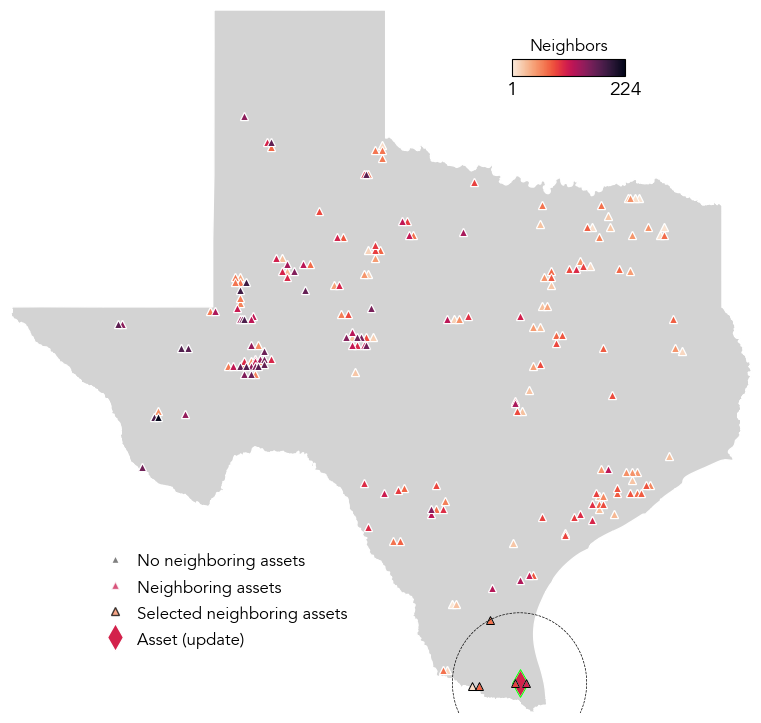

In [11]:
_fig, _ax = plt.subplots(figsize=(7.5, 7.5), constrained_layout=True)

plotter.plot_frequency_map(
    _fig, _ax, palette_, 
    _TX, _fdu, X_tr_, X_ts_, _fdu.x_, _fdu.idx_neighbors_,
    _fdu.idx_temporal_, _fdu.idx_spatial_, _fdu.sigma,
    marker = '^',
)

_ax.legend(
    frameon=False, 
    bbox_to_anchor=(0.475, 0.25), 
    ncol=1, 
    fontsize=12
)

plt.savefig(IMAGES / f"spatial_neiboring_assets-{file_name}.pdf")

plt.show()

 /var/folders/0c/ffx2kgyn7xq4krqrpsv67l3m0000gn/T/ipykernel_32573/977222551.py:11: UserWarning:constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
 /var/folders/0c/ffx2kgyn7xq4krqrpsv67l3m0000gn/T/ipykernel_32573/977222551.py:11: UserWarning:constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
 /Users/Guille/opt/anaconda3/envs/py38/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning:constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.


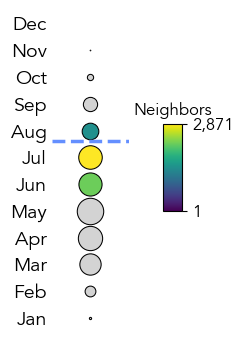

In [17]:
_fig, _ax = plt.subplots(figsize=(1, 4), constrained_layout=True)

plotter.scenarios_frequency_dates(
    _fig, _ax, palette_,
    _fdu.idx_neighbors_, _fdu.idx_temporal_, _fdu.idx_spatial_,
    T_tr_[:, interval], _fdu.date,
    scale=.1,
    colorbar=True,
)

plt.savefig(IMAGES / f"temporal_neiboring_assets-{file_name}.pdf")

plt.show()

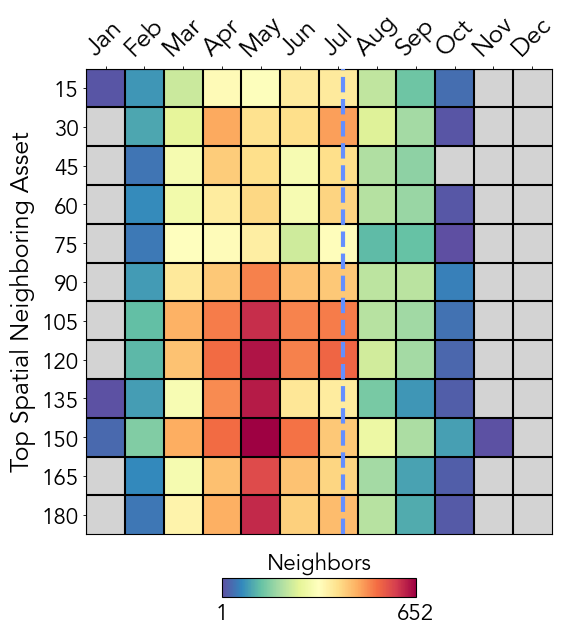

In [13]:
fig, _ax = plt.subplots(figsize=(7.5, 6.25), constrained_layout=True)

plotter.selected_scenarios_heatmap(
    _fig, _ax, palette_,
    _fdu._haversine_dist, _fdu.idx_neighbors_, _fdu.d_spatial_,
    _fdu.x_, T_tr_[:, interval], X_ts_,
    _fdu.date,
    colorbar=True,
)

plt.savefig(IMAGES / f"seasonly_neiboring_assets-{file_name}.pdf")

plt.show()

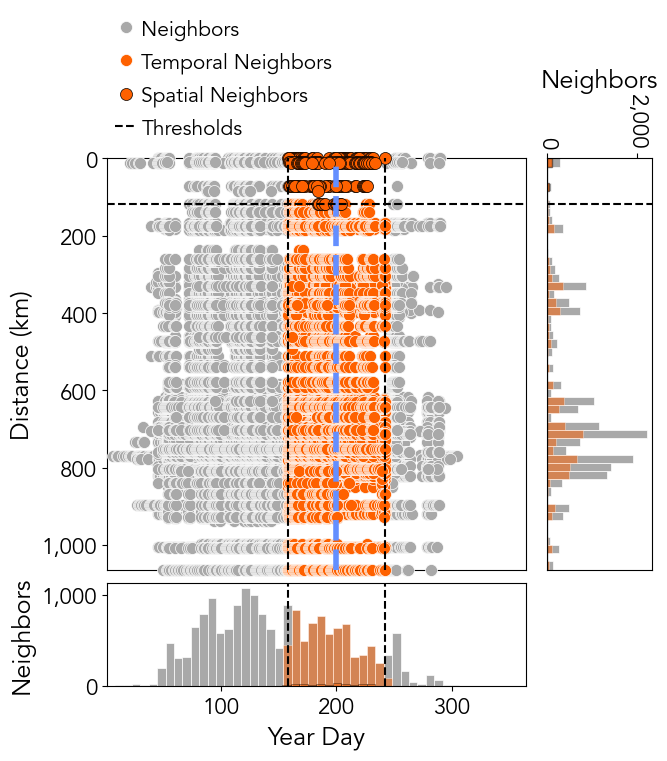

In [14]:
_fig, _ax = plt.subplot_mosaic(
    [["A", "B"], ["C", "."]],
    figsize=(6.5, 7.5),
    layout="constrained",
    gridspec_kw=dict(width_ratios=(1, 0.25), height_ratios=(1, 0.25)),
)

plotter.plot_filtered_scenarios(
    _fig, _ax["A"], palette_,
    _fdu.idx_neighbors_, _fdu.idx_temporal_, _fdu.idx_spatial_, _fdu.d_spatial_,
    t_tr_, t_ts_[day], _fdu.sigma, _fdu.window, _fdu.gamma_prime,
)

plotter.plot_distance_histogram(
    _fig, _ax["B"], palette_,
    _fdu.idx_neighbors_, _fdu.idx_temporal_, _fdu.idx_spatial_,
    _fdu.d_spatial_, _fdu.sigma,
)

plotter.plot_dates_histogram(
    _fig, _ax["C"], palette_,
    _fdu.idx_neighbors_, _fdu.idx_temporal_, _fdu.idx_spatial_, _fdu.d_spatial_,
    t_tr_, t_ts_[day], _fdu.window, _fdu.gamma_prime,
)

_ax["A"].legend(
    frameon=False,
    ncol=1,
    columnspacing=0.625,
    handletextpad=0.25,
    loc=(0.0, 1.025),
    fontsize=15,
)

plt.savefig(IMAGES / f"kNN_frequency-{file_name}.pdf")

plt.show()

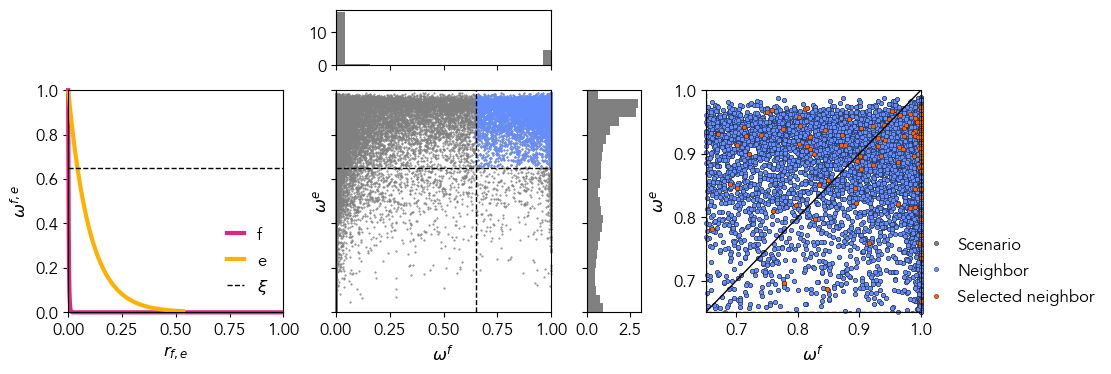

In [15]:
fig, _ax = plt.subplot_mosaic(
    [[".", ".", "e", ".", ".", "."],
     ["A", "A", "B", "f", "C", "C"],
     ["A", "A", "B", "f", "C", "C"],],
    figsize=(11, 3.625),
    layout="constrained",
    gridspec_kw=dict(width_ratios=(2, 2, 4, 1, 2, 2), height_ratios=(1, 2, 2)),
)

plotter.plot_density_threshold(
    _fig, _ax["A"], palette_, 
    _fdu.d_f_, _fdu.d_e_, _fdu.w_f_, _fdu.w_e_, _fdu.xi)

plotter.plot_functional_neighborhood(
    _fig, _ax["B"], _ax["e"], _ax["f"], palette_, 
    _fdu.idx_neighbors_, _fdu.w_f_, _fdu.w_e_, _fdu.xi
)

plotter.plot_selected_functional_neighbors(
    _fig, _ax["C"], palette_, _fdu.idx_neighbors_, _fdu.idx_temporal_,
    _fdu.idx_spatial_, _fdu.w_f_, _fdu.w_e_, _fdu.w_, _fdu.xi,
)

_ax["C"].legend(
    frameon=False, 
    fontsize=12, 
    ncol=1, 
    loc=(1.0, 0.0)
)

plt.savefig(IMAGES / f"fneighbor-{file_name}.pdf")

plt.show()

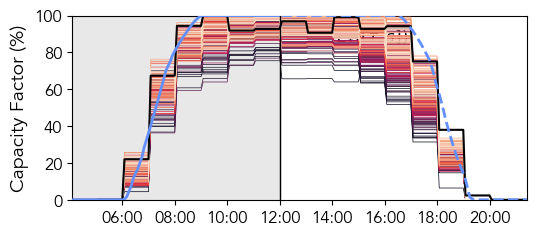

In [41]:
_fig, _ax = plt.subplots(figsize = (5.25, 2.25), constrained_layout = True)

plotter.plot_forecasts(
    _fig, _ax, palette_, E_tr_biased_, _fdu.w_, _fdu.idx_spatial_, 
    f_, f_hat_, e_biased_, dx_, dt_ + 5, interval,
    range_=[48, 256],
    legend=False,
)

_ax.legend(
    loc=(0.5, 0.8),
    frameon=False,
    fontsize=12,
    ncol=1
)

plt.savefig(IMAGES / f"dayahead_neighbors-{file_name}.pdf")

plt.show()

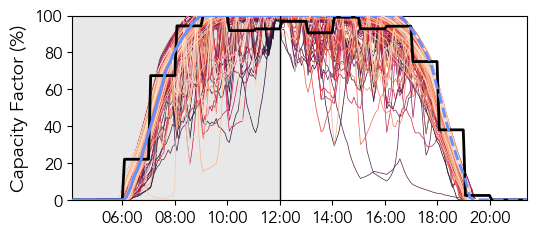

In [42]:
_fig, _ax = plt.subplots(figsize = (5.25, 2.25), constrained_layout = True)

plotter.plot_neighbors(
    _fig, _ax, palette_, F_tr_, _fdu.w_, _fdu.idx_spatial_, 
    f_, f_hat_, e_biased_, dx_, dt_ + 5, interval,
    range_=[48, 256],
)

_ax.legend(
    loc=(0.5, 0.8),
    frameon=False,
    fontsize=12,
    ncol=1
)

plt.savefig(IMAGES / f"partial_neighbors-{file_name}.pdf")

plt.show()

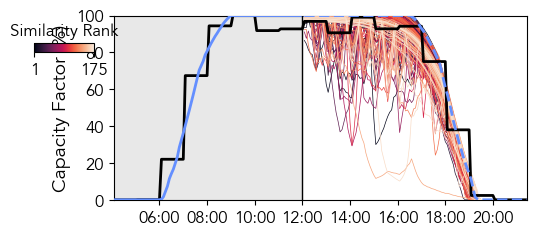

In [43]:
_fig, _ax = plt.subplots(figsize = (5.25, 2.25), constrained_layout = True)

plotter.plot_updates(
    _fig, _ax, palette_, M_, f_, f_hat_, e_biased_, 
    _fdu.w_, _fdu.idx_spatial_, dx_, dt_ + 5, interval,
    range_=[48, 256],
)

_ax.legend(
    loc=(0.5, 0.8),
    frameon=False,
    fontsize=12,
    ncol=1
)

plt.savefig(IMAGES / f"dynamic_update_neighbors-{file_name}.pdf")

plt.show()

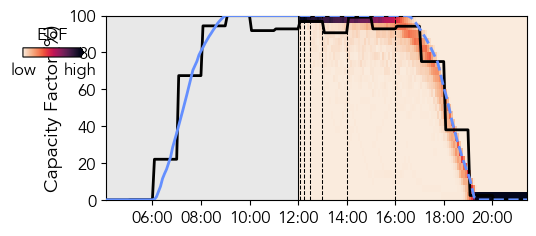

In [44]:
slices_ = [3, 6, 12, 24, 48]

_fig, _ax = plt.subplots(figsize = (5.25, 2.25), constrained_layout = True)

plotter.plot_heatmap_slices(
    _fig, _ax, palette_, _fdu.M_, f_, f_hat_, 
    e_biased_, dx_, dt_ + 5, interval,
    slices_ = slices_,
    range_=[48, 256],
    colorbar = True,
)

# _ax.legend(
#     loc=(0.15, 1), 
#     frameon=False, 
#     fontsize=12, 
#     ncol=4
# )

plt.savefig(IMAGES / f"heatmap-{file_name}.pdf")

plt.show()

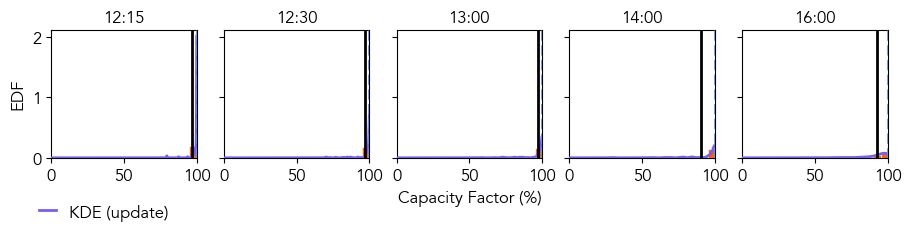

In [22]:
KDs_ = _fdu.kernel_density_estimation(
    100.*M_, 
    algorithm="auto", 
    kernel="gaussian"
)

_fig, _ax = plt.subplots(
    1, len(slices_), 
    figsize=(9, 2.25), 
    sharey=True, 
    layout="constrained"
)

plotter.plot_histogram_cuts(
    _fig, _ax, palette_, 
    KDs_, M_, f_, f_hat_, e_biased_, dx_, dt_, interval, 
    slices_ = slices_)

_ax[0].legend(
    frameon=False, 
    fontsize=12, 
    loc=(-0.125, -0.55)
)

plt.savefig(IMAGES / f"marginal_density_cutoffs-{file_name}.pdf")

plt.show()

In [46]:
F_curves_ = []
M_curves_ = []
D_curves_ = []
for interval in range(12, 276, 12):

    M_ = _fdu.predict(
        F_ts_[day, :interval, asset],
        E_ts_lin_[day, :, asset],
        X_ts_[asset, :],
        t_ts_[day],
        forget_rate_f=get_hyper(hyper_, "forget_rate_f", interval),
        forget_rate_e=get_hyper(hyper_, "forget_rate_e", interval),
        length_scale_f=get_hyper(hyper_, "length_scale_f", interval),
        length_scale_e=get_hyper(hyper_, "length_scale_e", interval),
        lookup_rate=get_hyper(hyper_, "lookup_rate", interval),
        trust_rate=get_hyper(hyper_, "trust_rate", interval),
        nu=get_hyper(hyper_, "nu", interval),
        gamma=get_hyper(hyper_, "gamma", interval),
        xi=get_hyper(hyper_, "xi", interval),
        kappa=get_hyper(hyper_, "kappa", interval),
        p_fusion=get_hyper(hyper_, "p_fusion", interval),
    )

    # Compute depth to find the focal curve
    _F = FDataGrid(data_matrix=_fdu.M_, grid_points=_fdu.dt_[interval:])

    depth_rank_ = np.argsort(_depth(_F))[::-1]

    M_curves_.append(np.median(_fdu.M_, axis=0))
    F_curves_.append(_fdu.f_focal_)
    D_curves_.append(_fdu.M_[depth_rank_[0], :])

print(len(F_curves_), len(M_curves_), len(D_curves_))

 /Users/Guille/Desktop/dynamic_update/functional_forecast_dynamic_update/src/fdu.py:55: RuntimeWarning:invalid value encountered in true_divide


22 22 22


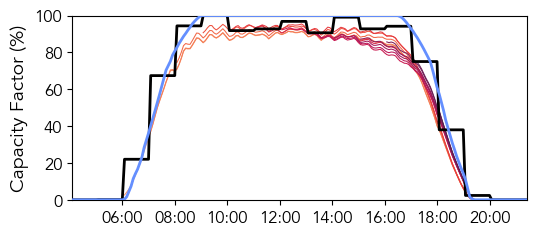

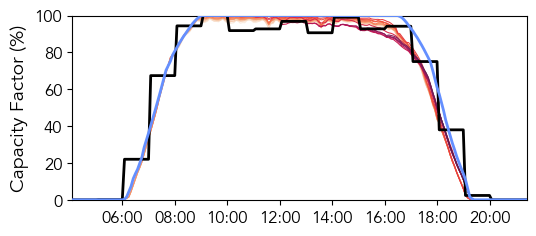

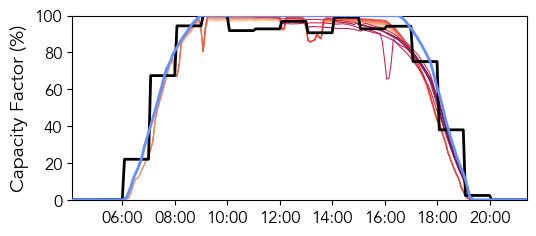

In [47]:
_fig, _ax = plt.subplots(figsize = (5.25, 2.25), constrained_layout = True)

plotter.plot_dynamic_update(
    _fig, _ax, palette_, 
    F_curves_, f_, f_hat_, e_biased_, dx_, dt_ + 5,
    label="Focal curves",
    range_=[48, 256],
    legend=True,
    colorbar=False,
)

# _ax.legend(
#     loc=(0.2, 0.0125), 
#     frameon=False, 
#     fontsize=12, 
#     ncol=3
# )

plt.savefig(IMAGES / f"dynamic_update-focal_curve-{file_name}.pdf")

plt.show()

_fig, _ax = plt.subplots(figsize = (5.25, 2.25), constrained_layout = True)

plotter.plot_dynamic_update(
    _fig, _ax, palette_, 
    M_curves_, f_, f_hat_, e_biased_, dx_, dt_ + 5, 
    range_=[48, 256],
    legend=True,
    colorbar=False,
    label="Marginal medians"
)

# _ax.legend(
#     loc=(0.25, 0.0), 
#     frameon=False, 
#     fontsize=12, 
#     ncol=3
# )

plt.savefig(IMAGES / f"dynamic_update-median_marginals-{file_name}.pdf")

plt.show()

_fig, _ax = plt.subplots(figsize = (5.25, 2.25), constrained_layout = True)

plotter.plot_dynamic_update(
    _fig, _ax, palette_, 
    D_curves_, f_, f_hat_, e_biased_, dx_, dt_ + 5, 
    range_=[48, 256],
    legend=True,
    colorbar=False,
    label="Deepest curves"
)

# _ax.legend(
#     loc=(0.25, 0.0), 
#     frameon=False, 
#     fontsize=12, 
#     ncol=3
# )

plt.savefig(IMAGES / f"dynamic_update-deepest_curve-{file_name}.pdf")

plt.show()

(76593,) (190,) (6532, 2) (190, 2)


 /Users/Guille/opt/anaconda3/envs/py38/lib/python3.8/site-packages/cartopy/mpl/gridliner.py:844: ShapelyDeprecationWarning:__len__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Check the length of the `geoms` property instead to get the  number of parts of a multi-part geometry.
 /Users/Guille/opt/anaconda3/envs/py38/lib/python3.8/site-packages/cartopy/mpl/gridliner.py:855: ShapelyDeprecationWarning:Iteration over multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
 /Users/Guille/opt/anaconda3/envs/py38/lib/python3.8/site-packages/cartopy/mpl/gridliner.py:850: ShapelyDeprecationWarning:__getitem__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
 <__array_function__ internals>:5: ShapelyDeprecationWarning:The array interface is deprecated and will

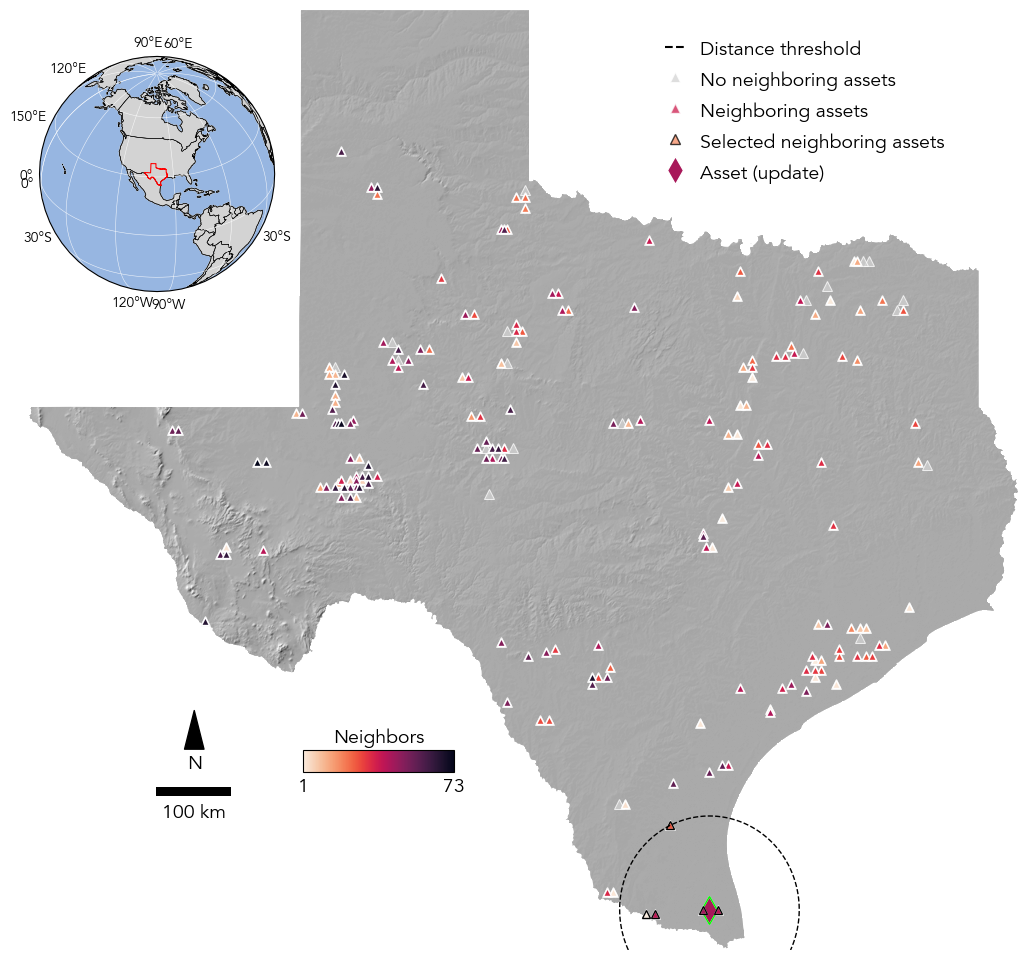

In [119]:
_fig, _ax = plt.subplots(1, 1, figsize=(10, 10), layout="constrained")

# Add an inset globe showing Texas
plotter.globe_inset(
    _fig, _ax, _TX, 
    x0=0.005, 
    y0=0.7, 
    width=0.25, 
    height=0.25
)

_fig, _ax = plotter.hillshade(_fig, _ax, _TX)

plotter.plot_hillshade_frequency_map(
    _fig, _ax, palette_, _TX, _fdu, X_tr_, X_ts_, _fdu.x_, 
    _fdu.idx_neighbors_, _fdu.idx_temporal_, _fdu.idx_spatial_, _fdu.sigma,
    marker = '^',
)

# Add compass (North arrow)
x = 0.1675
y = 0.2575
arrow_length = 0.06  # relative axes coords

_ax.annotate(
    "N",
    xy=(x, y),
    xytext=(x, y - arrow_length),
    arrowprops=dict(facecolor="k", 
                    arrowstyle="wedge,tail_width=1,shrink_factor=.5"),
    ha="center",
    va="center",
    fontsize=14,
    xycoords=_ax.transAxes,
)

scalebar = ScaleBar(
    dx=100,  # scaling factor
    units="km",
    dimension="si-length",  # could also be 'imperial-length.'
    location="lower left",
    length_fraction=0.09,  # fraction of the axis for bar length
    color="black",
    box_color="None",
    box_alpha=1.0,
    border_pad=9,
    font_properties={"size": 14},
)

_ax.add_artist(scalebar)

_ax.legend(
    frameon=False, 
    bbox_to_anchor=(0.625, 0.9875), 
    ncol=1, 
    fontsize=14
)

plt.savefig(IMAGES / f"hillshade_neighboring_assets-{file_name}.pdf")

plt.show()

In [ ]:
# # solar asset
# resource = 'solar'
# type = 'asset'
# description = 1
# method = 'fusion'
# score = 'FCS'

# hyper_, envelope_, validation_ = _load_hyperparamerters(resource, method, type, score, description, 
#                                                         path = path_to_validation)

# # interval = 120
# # lead = 12
# # horizon = [0, 12, 24, 36, 48, 60][2]
# interval = 144 
# lead = 9
# horizon = [0, 9, 18, 27, 36, 45][2]
# # interval = 168 
# # lead = 6
# # horizon = [0, 6, 12, 18, 24, 30][2]

# pit_ = _load_pit(validation_, resource, method, type, interval, description, 
#                  path = path_to_validation)

# print(pit_.shape)

# _fig, _ax = plt.subplots(1, 1, 
#                         figsize = (2.3, 2.25), 
#                         layout  = "constrained")

# _plot_PIT(_ax, pit_[:, horizon:(horizon + lead)].flatten(), 
#           bins = 10,
#           xlabel = 'PIT (1h to 48h lead)')

# # plt.savefig(path_to_images + f"/PIT-{resource}-{method}-{type}-{interval}-{horizon}.pdf", 
# #             bbox_inches="tight")


# plt.show()